<a href="https://colab.research.google.com/github/KuroNeko5536/JeongMan-v6-Robotic-Arm/blob/main/JeongMan6_data_generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

In [ ]:
def get_trans(theta, link_length):
  A0 = np.array([
      [np.cos(theta[0]), -np.sin(theta[0]), 0, 0],
      [np.sin(theta[0]),  np.cos(theta[0]), 0, 0],
      [0, 0, 1, 0],
      [0, 0, 0, 1]
  ])

  A1 = np.array([
      [np.cos(theta[1]), 0, -np.sin(theta[1]), link_length[0]],
      [0, 1, 0, 0],
      [np.sin(theta[1]), 0, np.cos(theta[1]), 0],
      [0, 0, 0, 1]
  ])

  theta2_prime = theta[2] + np.radians(71.9)

  A2 = np.array([
      [np.cos(theta2_prime), 0, -np.sin(theta2_prime), 0],
      [0, 1, 0, 0],
      [np.sin(theta2_prime), 0, np.cos(theta2_prime), link_length[1]],
      [0, 0, 0, 1]
  ])

  A3 = np.array([
      [1, 0, 0, link_length[2][0]],
      [0, np.cos(theta[3]), -np.sin(theta[3]), 0],
      [0, np.sin(theta[3]), np.cos(theta[3]), link_length[2][1]],
      [0, 0, 0, 1]
  ])

  A4 = np.array([
      [np.cos(theta[4]), 0, -np.sin(theta[4]), 0],
      [0, 1, 0, 0],
      [np.sin(theta[4]), 0, np.cos(theta[4]), 0],
      [0, 0, 0, 1]
  ])

  A5 = np.array([
      [1, 0, 0, link_length[3]],
      [0, 1, 0, 0],
      [0, 0, 1, 0],
      [0, 0, 0, 1],
  ])

  A = [A0, A1, A2, A3, A4, A5]

  T = np.eye(4)

  joints = [[0, 0, 0]]

  for Ai in A:
      T = T @ Ai
      joints.append(T[:3, 3].copy())

  return np.array(joints)

In [ ]:
degrees = [30, 45, -30, 45, 30]

theta_current = np.radians(degrees)

link_length = [100, 333, [117, 358], 100]

result = get_trans(theta_current, link_length)

print(result)

[[   0.            0.            0.        ]
 [   0.            0.            0.        ]
 [  86.60254038   50.            0.        ]
 [-117.31748071  -67.73327907  235.46655814]
 [-421.42135456 -243.3077325   371.65556361]
 [-421.42135456 -243.3077325   371.65556361]
 [-430.2615907  -289.23647426  460.04335069]]


In [ ]:
max_rotatoin = [180, 50, 75, 90, 60]
min_rotatoin = [-180, -90, -75, -90, -60]

link_length = [100, 333, [117, 358], 100]

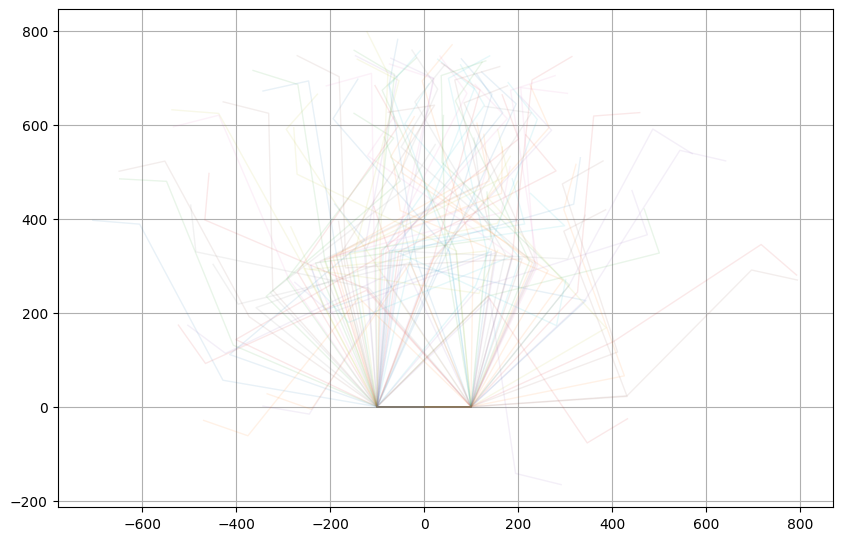

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

samples = 20000
slice_thickness = 10

workspace_points = []

fig, ax = plt.subplots(figsize=(10, 10))

for _ in range(samples):

    theta = np.radians([
        np.random.uniform(min_rotatoin[0], max_rotatoin[0]),
        np.random.uniform(min_rotatoin[1], max_rotatoin[1]),
        np.random.uniform(min_rotatoin[2], max_rotatoin[2]),
        np.random.uniform(min_rotatoin[3], max_rotatoin[3]),
        np.random.uniform(min_rotatoin[4], max_rotatoin[4]),
    ])

    joints = get_trans(theta, link_length)

    end_effector = joints[-1]

    workspace_points.append(end_effector)

    if np.all(np.abs(joints[:,1]) < slice_thickness):

        ax.plot(
            joints[:,0],
            joints[:,2],
            linewidth=1,
            alpha=0.1
        )

workspace_points = np.array(workspace_points)

ax.set_aspect('equal')

ax.grid(True)

plt.show()

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

min_rotation = torch.tensor([-180.0, -90.0, -75.0, -90.0, -60.0], device=device)
max_rotation = torch.tensor([180.0, 50.0, 75.0, 90.0, 60.0], device=device)

link_length = [100, 333, [117, 358], 100]

def torch_gen_dataset(num_samples=5_000_000):
    rand_ratios = torch.rand(num_samples, 5, device=device)
    theta_deg = min_rotation + (max_rotation - min_rotation) * rand_ratios
    theta = torch.deg2rad(theta_deg)

    cos0, sin0 = torch.cos(theta[:, 0]), torch.sin(theta[:, 0])
    cos1, sin1 = torch.cos(theta[:, 1]), torch.sin(theta[:, 1])

    theta2_prime = theta[:, 2] + torch.deg2rad(torch.tensor(71.9, device=device))
    cos2, sin2 = torch.cos(theta2_prime), torch.sin(theta2_prime)

    cos3, sin3 = torch.cos(theta[:, 3]), torch.sin(theta[:, 3])
    cos4, sin4 = torch.cos(theta[:, 4]), torch.sin(theta[:, 4])

    zeros = torch.zeros(num_samples, device=device)
    ones = torch.ones(num_samples, device=device)

    A0 = torch.stack([
        torch.stack([cos0, -sin0, zeros, zeros], dim=1),
        torch.stack([sin0,  cos0, zeros, zeros], dim=1),
        torch.stack([zeros, zeros, ones,  zeros], dim=1),
        torch.stack([zeros, zeros, zeros, ones],  dim=1)
    ], dim=1)

    A1 = torch.stack([
        torch.stack([cos1, zeros, -sin1, ones * link_length[0]], dim=1),
        torch.stack([zeros, ones, zeros, zeros], dim=1),
        torch.stack([sin1, zeros, cos1, zeros], dim=1),
        torch.stack([zeros, zeros, zeros, ones], dim=1)
    ], dim=1)

    A2 = torch.stack([
        torch.stack([cos2, zeros, -sin2, zeros], dim=1),
        torch.stack([zeros, ones, zeros, zeros], dim=1),
        torch.stack([sin2, zeros, cos2, ones * link_length[1]], dim=1),
        torch.stack([zeros, zeros, zeros, ones], dim=1)
    ], dim=1)

    A3 = torch.stack([
        torch.stack([ones, zeros, zeros, ones * link_length[2][0]], dim=1),
        torch.stack([zeros, cos3, -sin3, zeros], dim=1),
        torch.stack([zeros, sin3, cos3, ones * link_length[2][1]], dim=1),
        torch.stack([zeros, zeros, zeros, ones], dim=1)
    ], dim=1)

    A4 = torch.stack([
        torch.stack([cos4, zeros, -sin4, zeros], dim=1),
        torch.stack([zeros, ones, zeros, zeros], dim=1),
        torch.stack([sin4, zeros, cos4, zeros], dim=1),
        torch.stack([zeros, zeros, zeros, ones], dim=1)
    ], dim=1)

    A5 = torch.stack([
        torch.stack([ones, zeros, zeros, ones * link_length[3]], dim=1),
        torch.stack([zeros, ones, zeros, zeros], dim=1),
        torch.stack([zeros, zeros, ones, zeros], dim=1),
        torch.stack([zeros, zeros, zeros, ones], dim=1)
    ], dim=1)

    T = torch.eye(4, device=device).unsqueeze(0).repeat(num_samples, 1, 1)
    T = torch.bmm(T, A0)
    T = torch.bmm(T, A1)
    T = torch.bmm(T, A2)
    T = torch.bmm(T, A3)
    T = torch.bmm(T, A4)
    T = torch.bmm(T, A5)

    ee_xyz = T[:, :3, 3]

    r11 = T[:, 0, 0]
    r21 = T[:, 1, 0]
    r31 = T[:, 2, 0]
    r32 = T[:, 2, 1]
    r33 = T[:, 2, 2]

    ee_yaw = torch.atan2(r21, r11)
    ee_pitch = torch.atan2(-r31, torch.sqrt(r32**2 + r33**2))
    ee_roll = torch.atan2(r32, r33)

    ee_angles = torch.stack([ee_roll, ee_pitch, ee_yaw], dim=1)

    theta_np = theta.cpu().numpy()
    xyz_np = ee_xyz.cpu().numpy()
    angles_np = ee_angles.cpu().numpy()

    full_dataset = np.hstack([theta_np, xyz_np, angles_np])

    columns = ['theta1', 'theta2', 'theta3', 'theta4', 'theta5']
    columns += ['ee_x', 'ee_y', 'ee_z']
    columns += ['ee_roll', 'ee_pitch', 'ee_yaw']

    df = pd.DataFrame(full_dataset, columns=columns)
    df.to_csv('jeongman6_dataest.csv', index=False)
    print(f"dataset saved Shape: {df.shape}")

    return df

In [ ]:
torch_gen_dataset()

Dataset saved successfully! Shape: (5000000, 11)


,theta1,theta2,theta3,theta4,theta5,ee_x,ee_y,ee_z,ee_roll,ee_pitch,ee_yaw
0,0.664213,0.429432,0.086959,-0.023951,-0.856667,-275.882263,-218.280350,425.355286,0.007817,-0.914545,0.634549
1,1.128455,0.506364,-1.178069,0.298062,-0.821659,-47.514523,-50.079071,633.543701,0.253381,0.210825,1.350183
2,-2.301371,-1.487174,0.619546,0.531691,-0.368317,-322.106018,-386.867188,409.985260,0.489790,-0.065015,-2.117409
3,0.347981,-0.546094,-0.495826,-1.257292,0.603968,346.679810,183.223160,693.725464,-1.433920,-0.352405,0.961326
4,-0.515981,-0.642990,-0.278179,-1.053384,0.145402,340.289246,-178.547546,682.257812,-1.102895,-0.402609,-0.378682
...,...,...,...,...,...,...,...,...,...,...,...
4999995,-1.720589,-0.542496,-0.989752,-1.546455,-0.792866,-152.421387,-532.716675,576.586609,-1.754483,0.210389,-2.536301
4999996,1.223564,-1.416917,-0.828763,1.057456,0.004498,288.812439,796.902893,65.845261,1.051500,0.988568,1.216437
4999997,2.806801,-0.800066,-0.074004,0.834071,0.187430,-374.208130,144.795074,655.966858,0.901879,-0.502248,2.648684
4999998,2.088290,0.001964,-0.876788,-0.642551,-1.015255,-29.660196,155.019836,665.259277,-0.666627,0.451127,1.486984
